# Camp 1 — Storage & Structure
### Data GOLD Field Notes · Series Demo 02

Six terms, three comparisons: **Data Warehouse vs. Data Lake vs. Data Lakehouse**, a standalone look at **Schema**, and **Star Schema vs. Snowflake Schema**.

Each section is self-contained — run top to bottom, or jump to the term you're studying.


## Setup

In [1]:
import sqlite3
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


## Section A — Data Warehouse vs. Data Lake vs. Data Lakehouse

Same underlying sales activity, three different ways it could land. This is the comparison that matters — the terms only make sense next to each other.


### 1. Data Warehouse

Structured storage, modeled before it arrives. Query it the moment it lands.


In [3]:
warehouse_conn = sqlite3.connect(":memory:")
warehouse_conn.execute("""
    CREATE TABLE warehouse_sales (
        sale_id INTEGER,
        product TEXT,
        category TEXT,
        amount REAL
    )
""")

warehouse_sales = [
    {"sale_id": 1, "product": "CRM Suite",          "category": "Software", "amount": 4200.00},
    {"sale_id": 2, "product": "Laptop Dock",         "category": "Hardware", "amount": 350.00},
    {"sale_id": 3, "product": "Onboarding Package",  "category": "Services", "amount": 1500.00},
    {"sale_id": 4, "product": "CRM Suite",           "category": "Software", "amount": 4200.00},
    {"sale_id": 5, "product": "Server Rack",         "category": "Hardware", "amount": 2100.00},
]

warehouse_conn.executemany(
    "INSERT INTO warehouse_sales VALUES (:sale_id, :product, :category, :amount)",
    warehouse_sales,
)
warehouse_conn.commit()

print("Data Warehouse — structured, pre-modeled, ready to query on arrival:")
pd.read_sql("""
    SELECT category, COUNT(*) AS num_sales, SUM(amount) AS total_revenue
    FROM warehouse_sales
    GROUP BY category
    ORDER BY total_revenue DESC
""", warehouse_conn)


Data Warehouse — structured, pre-modeled, ready to query on arrival:


,category,num_sales,total_revenue
0,Software,2,8400.0
1,Hardware,2,2450.0
2,Services,1,1500.0


### 2. Data Lake

The exact same sales activity — but landing in whatever format each source system happened to produce. No shared schema enforced on the way in.


In [5]:
# Same 5 sales, landing raw — one as JSON, one as CSV text, one as a flat key=value string
data_lake = {
    "sale_1001.json": json.dumps({"sale_id": 1001, "product": "CRM Suite", "category": "Software", "amount": 4200.00}),
    "sale_1002.csv":  "sale_id,product,category,amount\n1002,Laptop Dock,Hardware,350.00",
    "sale_1003.txt":  "sale_id=1003; product=Onboarding Package; category=Services; amount=1500.00",
    "sale_1004.json": json.dumps({"sale_id": 1004, "product": "CRM Suite", "category": "Software", "amount": 4200.00}),
    "sale_1005.csv":  "sale_id,product,category,amount\n1005,Server Rack,Hardware,2100.00",
}

print("Data Lake — same sales activity, landed in whatever format each source produced:\n")
for filename, content in data_lake.items():
    print(f"  {filename}: {content}")

print("\nTo answer 'revenue by category' here, you'd have to parse three different formats")
print("before you could even start aggregating. That parsing effort is the cost of lake flexibility.")


Data Lake — same sales activity, landed in whatever format each source produced:

  sale_1001.json: {"sale_id": 1001, "product": "CRM Suite", "category": "Software", "amount": 4200.0}
  sale_1002.csv: sale_id,product,category,amount
1002,Laptop Dock,Hardware,350.00
  sale_1003.txt: sale_id=1003; product=Onboarding Package; category=Services; amount=1500.00
  sale_1004.json: {"sale_id": 1004, "product": "CRM Suite", "category": "Software", "amount": 4200.0}
  sale_1005.csv: sale_id,product,category,amount
1005,Server Rack,Hardware,2100.00

To answer 'revenue by category' here, you'd have to parse three different formats
before you could even start aggregating. That parsing effort is the cost of lake flexibility.


### 3. Data Lakehouse

Same raw lake files — but a schema-on-read layer normalizes them into one consistent shape the moment you query, so it behaves like a warehouse without a separate copy/load step.


In [7]:
def parse_lake_file(filename, content):
    if filename.endswith(".json"):
        return json.loads(content)
    elif filename.endswith(".csv"):
        header, row = content.strip().split("\n")
        return dict(zip(header.split(","), row.split(",")))
    elif filename.endswith(".txt"):
        return dict(pair.split("=") for pair in content.split("; "))
    else:
        raise ValueError(f"Unrecognized format: {filename}")

LAKEHOUSE_SCHEMA = {"sale_id": int, "product": str, "category": str, "amount": float}

def enforce_schema(record):
    return {field: caster(record[field]) for field, caster in LAKEHOUSE_SCHEMA.items()}

normalized = [enforce_schema(parse_lake_file(f, c)) for f, c in data_lake.items()]
lakehouse_df = pd.DataFrame(normalized)

print("Data Lakehouse — same raw lake files, normalized on read into one schema:\n")
print(lakehouse_df.to_string(index=False))

print("\nNow it queries like a warehouse, without ever copying the data into a separate system:")
lakehouse_df.groupby("category")["amount"].agg(num_sales="count", total_revenue="sum") \
    .reset_index().sort_values("total_revenue", ascending=False)


Data Lakehouse — same raw lake files, normalized on read into one schema:

 sale_id            product category  amount
    1001          CRM Suite Software  4200.0
    1002        Laptop Dock Hardware   350.0
    1003 Onboarding Package Services  1500.0
    1004          CRM Suite Software  4200.0
    1005        Server Rack Hardware  2100.0

Now it queries like a warehouse, without ever copying the data into a separate system:


,category,num_sales,total_revenue
2,Software,2,8400.0
0,Hardware,2,2450.0
1,Services,1,1500.0


## Section B — Schema

The defined shape of your data: fields, types, and the rules they follow. Below, one record that follows the rules and one that doesn't.


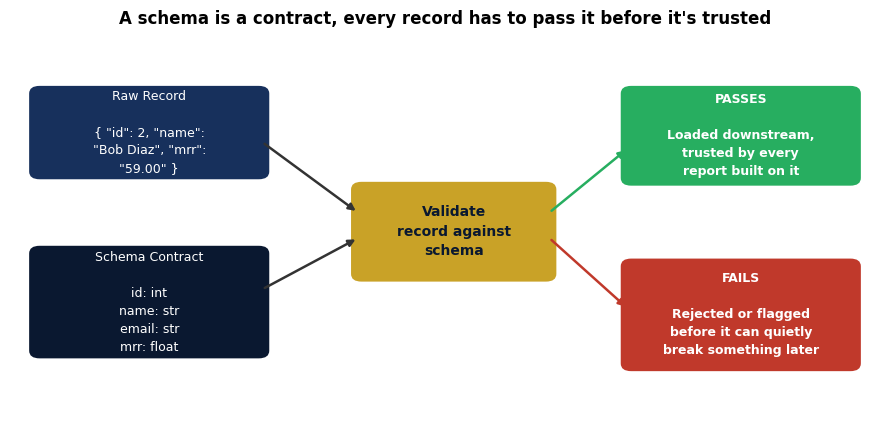

In [9]:
# Conceptual diagram: a schema is a contract a record has to pass before it's trusted downstream
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

def box(x, y, w, h, text, facecolor, textcolor="white", fontsize=10, fontweight="normal"):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=facecolor, edgecolor="none"
    ))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            color=textcolor, fontsize=fontsize, fontweight=fontweight, linespacing=1.5)

def arrow(x1, y1, x2, y2, color="#333333"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.8, shrinkA=2, shrinkB=2))

# Inputs
box(0.3, 4.0, 2.6, 1.3, "Raw Record\n\n{ \"id\": 2, \"name\":\n\"Bob Diaz\", \"mrr\":\n\"59.00\" }",
    facecolor="#17305C", fontsize=9)

box(0.3, 1.2, 2.6, 1.6,
    "Schema Contract\n\nid: int\nname: str\nemail: str\nmrr: float",
    facecolor="#0A1830", fontsize=9)

# Validation gate
box(4.0, 2.4, 2.2, 1.4, "Validate\nrecord against\nschema", facecolor="#C9A227", textcolor="#0A1830",
    fontsize=10, fontweight="bold")

arrow(2.9, 4.5, 4.0, 3.4)
arrow(2.9, 2.2, 4.0, 3.0)

# Outcomes
box(7.1, 3.9, 2.6, 1.4, "PASSES\n\nLoaded downstream,\ntrusted by every\nreport built on it",
    facecolor="#27AE60", fontsize=9, fontweight="bold")

box(7.1, 1.0, 2.6, 1.6, "FAILS\n\nRejected or flagged\nbefore it can quietly\nbreak something later",
    facecolor="#C0392B", fontsize=9, fontweight="bold")

arrow(6.2, 3.4, 7.1, 4.4, color="#27AE60")
arrow(6.2, 3.0, 7.1, 1.9, color="#C0392B")

ax.set_title("A schema is a contract, every record has to pass it before it's trusted",
             fontsize=12, fontweight="bold", pad=16)

plt.tight_layout()
plt.show()


In [11]:
customer_schema = {
    "id": int,
    "name": str,
    "email": str,
    "mrr": float,
}

def validate(record, schema):
    errors = []
    for field, expected_type in schema.items():
        if field not in record:
            errors.append(f"missing field '{field}'")
            continue
        if not isinstance(record[field], expected_type):
            errors.append(
                f"'{field}' expected {expected_type.__name__}, got {type(record[field]).__name__}"
            )
    return errors

good_record = {"id": 1, "name": "Priya K.", "email": "priya@example.com", "mrr": 129.00}
bad_record  = {"id": 2, "name": "Bob Diaz", "mrr": "59.00"}  # missing email, mrr is a string not a float

for label, record in [("good_record", good_record), ("bad_record", bad_record)]:
    errors = validate(record, customer_schema)
    if errors:
        print(f"{label}: FAILED schema validation")
        for e in errors:
            print(f"   - {e}")
    else:
        print(f"{label}: passed schema validation")


good_record: passed schema validation
bad_record: FAILED schema validation
   - missing field 'email'
   - 'mrr' expected float, got str


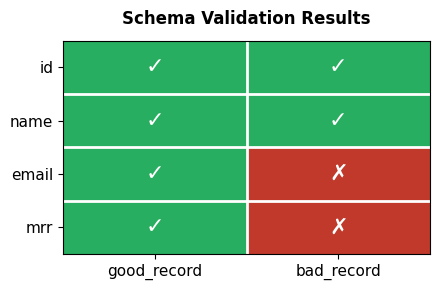

In [13]:
# Visualize the validation results as a color-coded grid: green check = valid, red X = invalid
records_to_check = {"good_record": good_record, "bad_record": bad_record}
fields = list(customer_schema.keys())

rows = []
for label, record in records_to_check.items():
    for field in fields:
        present = field in record
        valid = present and isinstance(record[field], customer_schema[field])
        rows.append({"record": label, "field": field, "valid": valid})

grid = pd.DataFrame(rows).pivot(index="field", columns="record", values="valid")
grid = grid[["good_record", "bad_record"]].loc[fields]  # keep schema field order

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.imshow(grid.values.astype(int), cmap=ListedColormap(["#C0392B", "#27AE60"]), vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(grid.columns)))
ax.set_xticklabels(grid.columns, fontsize=11)
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels(grid.index, fontsize=11)

for i in range(len(grid.index)):
    for j in range(len(grid.columns)):
        mark = "\u2713" if grid.values[i, j] else "\u2717"
        ax.text(j, i, mark, ha="center", va="center", color="white", fontsize=16, fontweight="bold")

ax.set_title("Schema Validation Results", fontsize=12, fontweight="bold", pad=12)
ax.set_xticks([x - 0.5 for x in range(1, len(grid.columns))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(grid.index))], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()


## Section C — Star Schema vs. Snowflake Schema

Same fact table, same business question — "total revenue by state" — run against two differently shaped models.


### 5. Star Schema

One fact table, joined straight out to its dimension tables.


In [15]:
star_conn = sqlite3.connect(":memory:")

star_conn.executescript("""
CREATE TABLE dim_customer (customer_id INTEGER, name TEXT, city TEXT, state TEXT, country TEXT);
CREATE TABLE dim_product  (product_id INTEGER, name TEXT, category TEXT);
CREATE TABLE fact_sales   (sale_id INTEGER, customer_id INTEGER, product_id INTEGER, amount REAL);
""")

customers = [
    (1, "Alicia Chen", "Charlotte", "NC", "USA"),
    (2, "Bob Diaz",     "Columbia",  "SC", "USA"),
    (3, "Priya K.",     "Charlotte", "NC", "USA"),
    (4, "Marcus Lee",   "Richmond",  "VA", "USA"),
]
products = [
    (1, "CRM Suite", "Software"),
    (2, "Laptop Dock", "Hardware"),
    (3, "Onboarding Package", "Services"),
]
sales = [
    (1, 1, 1, 4200.00),
    (2, 2, 2, 350.00),
    (3, 3, 3, 1500.00),
    (4, 1, 1, 4200.00),
    (5, 4, 2, 2100.00),
    (6, 3, 1, 4200.00),
]

star_conn.executemany("INSERT INTO dim_customer VALUES (?,?,?,?,?)", customers)
star_conn.executemany("INSERT INTO dim_product VALUES (?,?,?)", products)
star_conn.executemany("INSERT INTO fact_sales VALUES (?,?,?,?)", sales)
star_conn.commit()

print("Star schema — fact table joined directly to dim_customer, one hop:")
star_result = pd.read_sql("""
    SELECT c.state, SUM(f.amount) AS total_revenue
    FROM fact_sales f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    GROUP BY c.state
    ORDER BY total_revenue DESC
""", star_conn)
star_result


Star schema — fact table joined directly to dim_customer, one hop:


,state,total_revenue
0,NC,14100.0
1,VA,2100.0
2,SC,350.0


### 6. Snowflake Schema

Same fact table and the same six sales — but `dim_customer` is normalized further, splitting city and state out into their own tables.


In [17]:
snow_conn = sqlite3.connect(":memory:")

snow_conn.executescript("""
CREATE TABLE dim_state    (state_id INTEGER, state TEXT, country TEXT);
CREATE TABLE dim_city     (city_id INTEGER, city TEXT, state_id INTEGER);
CREATE TABLE dim_customer (customer_id INTEGER, name TEXT, city_id INTEGER);
CREATE TABLE dim_product  (product_id INTEGER, name TEXT, category TEXT);
CREATE TABLE fact_sales   (sale_id INTEGER, customer_id INTEGER, product_id INTEGER, amount REAL);
""")

states = [(1, "NC", "USA"), (2, "SC", "USA"), (3, "VA", "USA")]
cities = [(1, "Charlotte", 1), (2, "Columbia", 2), (3, "Richmond", 3)]
customers_normalized = [
    (1, "Alicia Chen", 1),
    (2, "Bob Diaz",     2),
    (3, "Priya K.",     1),
    (4, "Marcus Lee",   3),
]

snow_conn.executemany("INSERT INTO dim_state VALUES (?,?,?)", states)
snow_conn.executemany("INSERT INTO dim_city VALUES (?,?,?)", cities)
snow_conn.executemany("INSERT INTO dim_customer VALUES (?,?,?)", customers_normalized)
snow_conn.executemany("INSERT INTO dim_product VALUES (?,?,?)", products)
snow_conn.executemany("INSERT INTO fact_sales VALUES (?,?,?,?)", sales)
snow_conn.commit()

print("Snowflake schema — same question, now three hops instead of one:")
snow_result = pd.read_sql("""
    SELECT s.state, SUM(f.amount) AS total_revenue
    FROM fact_sales f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    JOIN dim_city ci     ON c.city_id = ci.city_id
    JOIN dim_state s     ON ci.state_id = s.state_id
    GROUP BY s.state
    ORDER BY total_revenue DESC
""", snow_conn)
snow_result


Snowflake schema — same question, now three hops instead of one:


,state,total_revenue
0,NC,14100.0
1,VA,2100.0
2,SC,350.0


In [19]:
print("Same question, two extra joins, identical answer:")
print(star_result.equals(snow_result))


Same question, two extra joins, identical answer:
True


---
### Recap

| Term | The one-line test |
|---|---|
| **Data Warehouse** | Is it structured and modeled *before* it lands? |
| **Data Lake** | Does it accept any format, with no schema enforced on the way in? |
| **Data Lakehouse** | Does a schema-on-read layer give lake storage warehouse-style queries? |
| **Schema** | Are there defined rules a record has to pass to be considered valid? |
| **Star Schema** | Is it one fact table, one hop out to each dimension? |
| **Snowflake Schema** | Are those dimensions normalized further, into more (and smaller) tables? |

**Data GOLD** — Turning data complexity into business GOLD.
